In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib




In [16]:
# Define the path to the Excel file
file_path = r"C:\Users\gokud\Downloads\Data-Resources\Data & Resources\Codes, Queries & DAX\prediction.xlsx"

# First, let's see what sheets are available in the Excel file
excel_file = pd.ExcelFile(file_path)
print("Available sheets:")
print(excel_file.sheet_names)

# Define the sheet name to read data from
sheet_name = excel_file.sheet_names[0]  # Use the first sheet

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Use the first row as column names
data.columns = data.iloc[0]
data = data.iloc[1:].reset_index(drop=True)

# Convert all column names to lowercase
data.columns = data.columns.str.lower()

# Display the first few rows of the fetched data
print(f"\nReading from sheet: '{sheet_name}'")
print(f"Column names: {data.columns.tolist()}")
print(f"\nData shape: {data.shape}")
print(data.head())

Available sheets:
['Sheet1']

Reading from sheet: 'Sheet1'
Column names: ['customer_id', 'gender', 'age', 'married', 'state', 'number_of_referrals', 'tenure_in_months', 'value_deal', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'customer_status', 'churn_category', 'churn_reason']

Data shape: (6007, 32)
0 customer_id  gender age married           state number_of_referrals  \
0   15776-UTT  Female  38     Yes   Uttar Pradesh                   1   
1   49302-GUJ  Female  47      No         Gujarat                  14   
2   39181-WES    Male  54     Yes     West Bengal                  10   
3   22915-MAH  Female  41     Yes     Mahar

In [18]:
# Data Preprocessing

# Drop columns that won't be used for prediction
data = data.drop(['customer_id', 'churn_category', 'churn_reason'], axis=1, errors='ignore')

# List of columns to be label encoded
columns_to_encode = [
    'gender', 'married', 'state', 'value_deal', 'phone_service', 'multiple_lines',
    'internet_service', 'internet_type', 'online_security', 'online_backup',
    'device_protection_plan', 'premium_support', 'streaming_tv', 'streaming_movies',
    'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
    'payment_method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    if column in data.columns:
        label_encoders[column] = LabelEncoder()
        data[column] = label_encoders[column].fit_transform(data[column].astype(str))

# Manually encode the target variable 'customer_status'
if 'customer_status' in data.columns:
    data['customer_status'] = data['customer_status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('customer_status', axis=1)
y = data['customer_status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
#Train Random Forest Model

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Confusion Matrix:
[[812  50]
 [117 223]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       862
           1       0.82      0.66      0.73       340

    accuracy                           0.86      1202
   macro avg       0.85      0.80      0.82      1202
weighted avg       0.86      0.86      0.86      1202



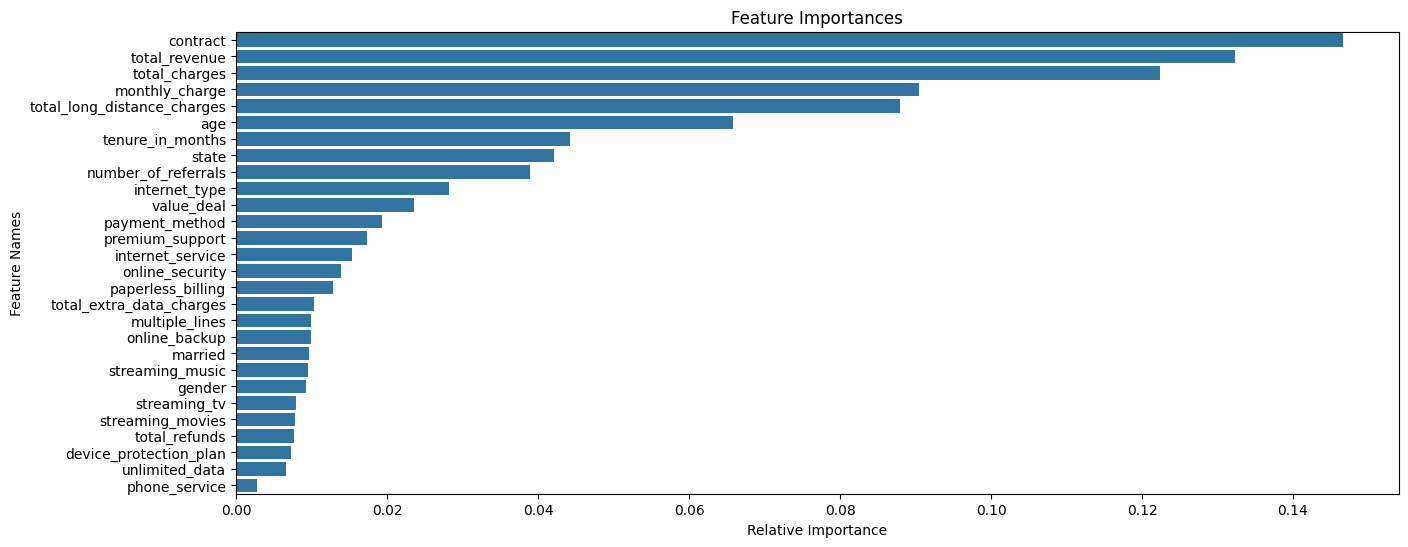

In [20]:
# Evaluate Model

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [25]:
#Use Model for Prediction on New Data

# Define the path to the Joiner Data Excel file
file_path = r"C:\Users\gokud\Downloads\Data-Resources\Data & Resources\Codes, Queries & DAX\prediction.xlsx"

# Check if file exists, if not, show available files
import os
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
    print("\nPlease update the file_path variable with the correct location of your Prediction_Data.xlsx file")
else:
    # List available sheets
    excel_file = pd.ExcelFile(file_path)
    print(f"Available sheets: {excel_file.sheet_names}")
    
    # Use the first sheet (or specify a different sheet name if needed)
    sheet_name = excel_file.sheet_names[0]
    
    # Read the data from the specified sheet into a pandas DataFrame
    new_data = pd.read_excel(file_path, sheet_name=sheet_name)
    
    # Use the first row as column names
    new_data.columns = new_data.iloc[0]
    new_data = new_data.iloc[1:].reset_index(drop=True)
    
    # Convert all column names to lowercase
    new_data.columns = new_data.columns.str.lower()
    
    # Display the first few rows of the fetched data
    print(f"\nReading from sheet: '{sheet_name}'")
    print(new_data.head())
    
    # Retain the original DataFrame to preserve unencoded columns
    original_data = new_data.copy()
    
    # Retain the customer_id column (if it exists)
    if 'customer_id' in new_data.columns:
        customer_ids = new_data['customer_id']
    
    # Drop columns that won't be used for prediction in the encoded DataFrame
    new_data = new_data.drop(['customer_id', 'customer_status', 'churn_category', 'churn_reason'], axis=1, errors='ignore')
    
    # Encode categorical variables using the saved label encoders
    for column in new_data.select_dtypes(include=['object']).columns:
        if column in label_encoders:
            new_data[column] = label_encoders[column].transform(new_data[column].astype(str))
    
    # Make predictions
    new_predictions = rf_model.predict(new_data)
    
    # Add predictions to the original DataFrame
    original_data['customer_status_predicted'] = new_predictions
    
    # Filter the DataFrame to include only records predicted as "Churned"
    churned_records = original_data[original_data['customer_status_predicted'] == 1]
    
    # Save the results
    churned_records.to_csv(r"C:\Users\gokud\OneDrive\Desktop\Resume_Projects\Data_analytics\Predictions.csv", index=False)
    print(f"\nPredictions saved! Found {len(churned_records)} records predicted as Churned.")

Available sheets: ['Sheet1']

Reading from sheet: 'Sheet1'
0 customer_id  gender age married           state number_of_referrals  \
0   15776-UTT  Female  38     Yes   Uttar Pradesh                   1   
1   49302-GUJ  Female  47      No         Gujarat                  14   
2   39181-WES    Male  54     Yes     West Bengal                  10   
3   22915-MAH  Female  41     Yes     Maharashtra                  10   
4   76712-AND  Female  42      No  Andhra Pradesh                  12   

0 tenure_in_months value_deal phone_service multiple_lines  ...  \
0               19       none            No             No  ...   
1                4       none            No             No  ...   
2                7       none            No             No  ...   
3               23       none            No             No  ...   
4                2       none            No             No  ...   

0   payment_method monthly_charge total_charges total_refunds  \
0  Bank Withdrawal          45.05 